<a href="https://colab.research.google.com/github/jldeato/HW6/blob/main/JD_HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns

##Q3
Please follow the instructions below and inspect the outputs before you proceed. You can always check this original final to compare your results in your own copy.

In [5]:
#You have to make sure that you were able to write the file to a csv while your were working in R
house=pd.read_csv('/content/drive/MyDrive/DSC502_DATA/DATA/house_prices.csv')
house.head()

,Unnamed: 0,date,state,unemploy_perc,house_price_index,house_price_perc
0,1,1976-01-01,Alabama,6.7,37.138285,0.040405
1,2,1976-02-01,Alabama,6.7,37.756437,0.051806
2,3,1976-03-01,Alabama,6.6,38.276319,0.059302
3,4,1976-04-01,Alabama,6.5,38.596135,0.059585
4,5,1976-05-01,Alabama,6.4,38.740517,0.055723


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


a) For the states below, please select the rows from the house dataframe, and consider converting the date column to date data type as it may be coming in string format. Then use the head function to preview your new dataframe.

In [6]:
states = ['Michigan', 'California', 'Texas', 'Indiana']

# convert to datetime
house["date"] = pd.to_datetime(house["date"])

house_states = house[house["state"].isin(states)]
house_states.head()


,Unnamed: 0,date,state,unemploy_perc,house_price_index,house_price_perc
2016,2017,1976-01-01,California,9.1,17.908764,0.139067
2017,2018,1976-02-01,California,9.1,18.117587,0.148485
2018,2019,1976-03-01,California,9.0,18.379530,0.151243
2019,2020,1976-04-01,California,9.0,18.673067,0.147308
2020,2021,1976-05-01,California,8.9,18.899995,0.143167


b) Use the FacetGrid from seaborn to create line plots to represent house_price_index for each state. Please make the line color red, set ticks on x axis for years ['1980', '2000', '2020'], which you may have to convert date type again, put those years as labels, and set the titles for each small plot to their state names. In addition, set the y label to 'house price index' and remove the x label since it's obvious that these are years.

/tmp/ipykernel_19785/3362949094.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  house_states["year"] = house_states["date"].dt.year


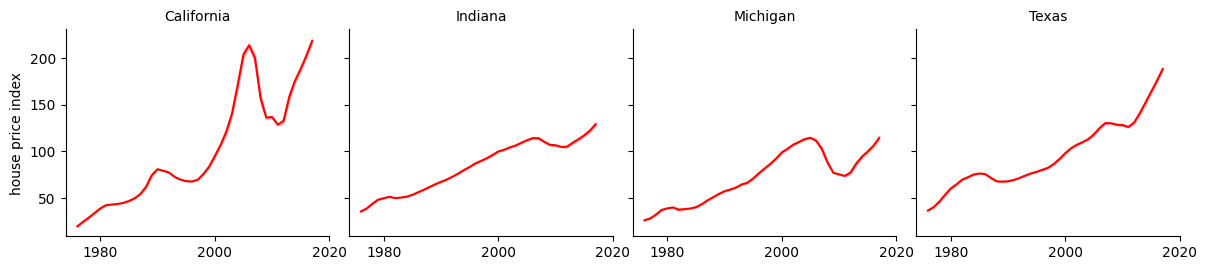

In [15]:
# use year
house_states["year"] = house_states["date"].dt.year

# use facetgrid
grid = sns.FacetGrid(house_states, col="state", height=3)

# plot red line
grid.map_dataframe(sns.lineplot, x = "year", y = "house_price_index", color="red")

# create titles
grid.set_titles(col_template="{col_name}")

# set x and y
grid.set_xlabels("")
grid.set_ylabels("house price index")

# set ticks
for ax in grid.axes.flat:
    ax.set_xticks([1980, 2000, 2020])
    ax.set_xticklabels(["1980", "2000", "2020"])





c) Draw a lineplot for 'house price perc', but color them based on the 'state' name which will have four lines in a single plot. Set a legend which will be at the bottom of your graph and have them horizantally positioned next to eachother. Again, set the y label to house_price_perc and remove the x label since it's obvious. (Note that my y label is still showing index. Please ignore that.)

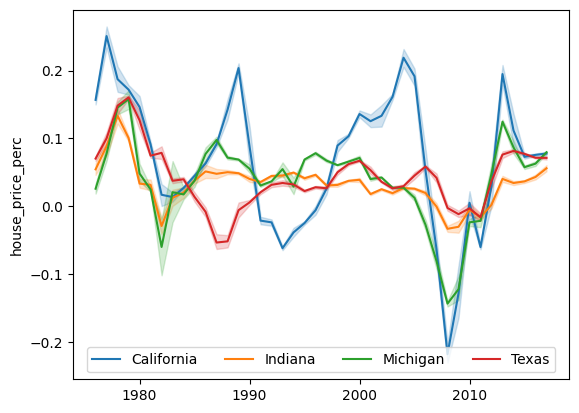

In [18]:
# create line plot
plot = sns.lineplot(data=house_states, x="year", y="house_price_perc", hue="state")

# edit labels
plot.set_xlabel("")
plot.set_ylabel("house_price_perc")

# fix legend
plot.legend(loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0))


##Q4
Please work on your 4th question below. Please feel free to add new code cells.

In [30]:
# read world cup data
world_cup = pd.read_csv('/content/drive/MyDrive/DSC502_DATA/DATA/WorldCupMatches.csv')
world_cup.head()

,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4,1,Mexico,,4444.0,3,0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201,1096,FRA,MEX
1,1930,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3,0,Belgium,,18346.0,2,0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201,1090,USA,BEL
2,1930,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2,1,Brazil,,24059.0,2,0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201,1093,YUG,BRA
3,1930,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3,1,Peru,,2549.0,1,0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201,1098,ROU,PER
4,1930,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1,0,France,,23409.0,0,0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201,1085,ARG,FRA


 Then using Pandas groupby feature on ’Home Team Initials’ and ’Away Team Initials’ find how many times these
countries’ national teams played a match. You can use the count() after grouping. These counts will be the
weight attribute when you create your final data frame explained below.

In [36]:
#your code goes here. Just leaving an example output of an intermediate step for you to check the last two columns
#A hint to start with:

team_pairs = world_cup.groupby(['Home Team Initials', 'Away Team Initials']).count().reset_index()

team_pairs = team_pairs[["Home Team Initials", "Away Team Initials", "Year"]]
team_pairs = team_pairs.rename(columns={"Year": "weight"})
team_pairs.head()


,Home Team Initials,Away Team Initials,weight
0,ALG,AUT,1
1,ALG,CHI,1
2,ALG,ESP,1
3,ALG,NIR,1
4,ALG,RUS,1


Find the total goals scored by each home team for the matches played above by using groupby as earlier and
sum on the ’Home Team Goals’ column. These summations will be your HomeGoalTotal’ attribute below.

In [37]:
home_team_goals = world_cup.groupby(["Home Team Initials", "Away Team Initials"])["Home Team Goals"].sum().reset_index()

home_team_goals = home_team_goals.rename(columns={"Home Team Goals": "HomeGoalTotal"})
home_team_goals.head()

,Home Team Initials,Away Team Initials,HomeGoalTotal
0,ALG,AUT,0
1,ALG,CHI,3
2,ALG,ESP,0
3,ALG,NIR,1
4,ALG,RUS,1


 Use the values you found above, come up with a new data frame called team_pairs which has ’Home Team
Initials’, ’Away Team Initials’, ’weight’, ’HomeGoalTotal’ columns where latter two columns should have the values
from your earlier steps.**bold text**

In [38]:
team_pairs = pd.merge(team_pairs, home_team_goals, on=["Home Team Initials", "Away Team Initials"])
team_pairs.head()

,Home Team Initials,Away Team Initials,weight,HomeGoalTotal
0,ALG,AUT,1,0
1,ALG,CHI,1,3
2,ALG,ESP,1,0
3,ALG,NIR,1,1
4,ALG,RUS,1,1


Write your team_pairs to a csv file by using Pandas to_csv feature. (Please ignore the fact that there may be
symmetric pairs such as ARG-BRA and BRA-ARG in your data frame. Please proceed what you have for the sake
of simplicity. If you can consolidate them, you can get 5 points bonus.)

Make sure that you only write four columns ('Home Team Initials', 'Away Team Initials', 'weight', 'HomeGoalTotal') from the data frame, team_pairs, to a csv file

In [40]:
team_pairs[
    ["Home Team Initials", "Away Team Initials", "weight", "HomeGoalTotal"]
].to_csv("/content/drive/MyDrive/DSC502_DATA/team_pairs.csv", index=False)